Task 2: Customer Segmentation using Unsupervised Learning

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [10]:
# Replace this path with where YOUR archive folder actually is
df = pd.read_csv(r'C:\Users\user\Downloads\archive\Mall_Customers.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [12]:
# Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [14]:
# Check column names
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


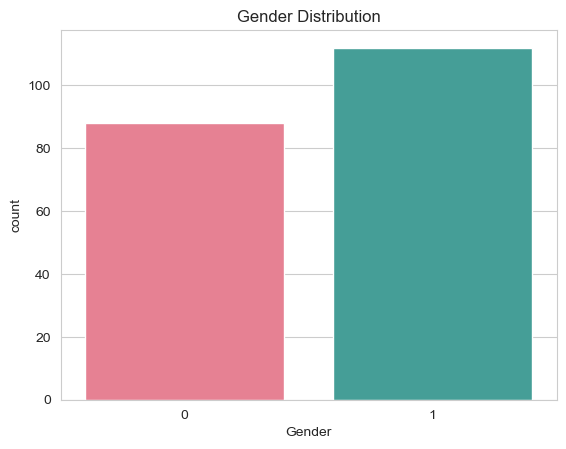

In [42]:
# Gender distribution
sns.countplot(x='Gender', data=df, palette='husl')
plt.title('Gender Distribution')
plt.show()

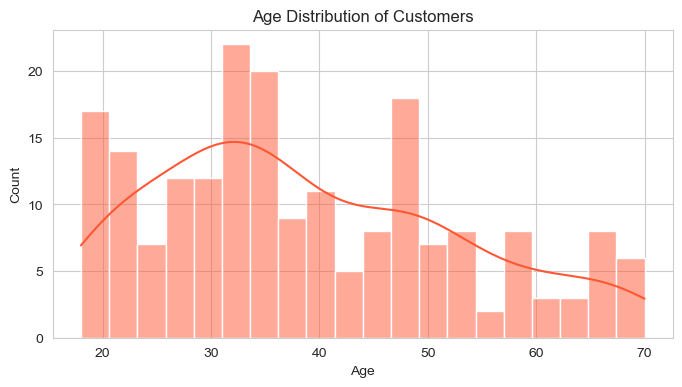

In [45]:
# Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='#FF5733')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.show()

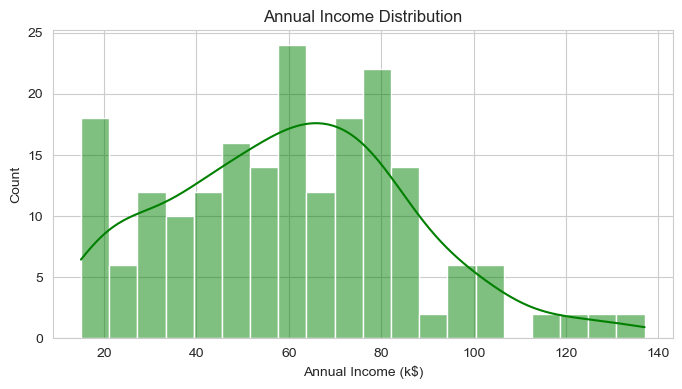

In [17]:
# Annual Income distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='green')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.show()

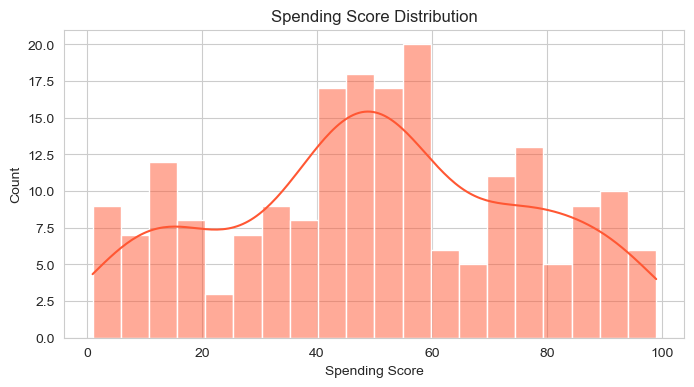

In [46]:
# Spending Score distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='#FF5733')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.show()

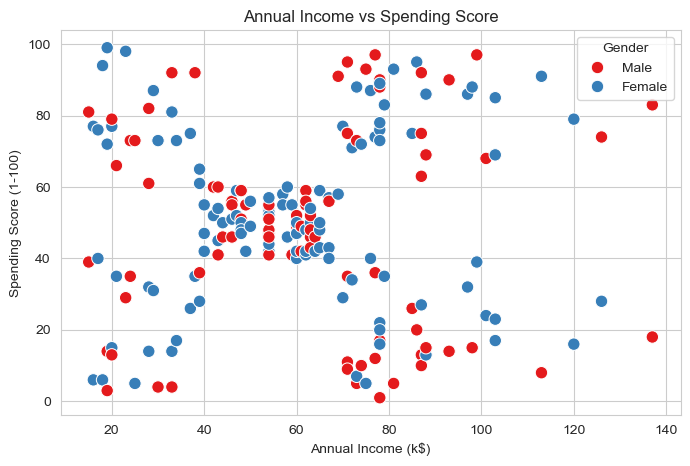

In [19]:
# Relationship between Income and Spending Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Gender', data=df, palette='Set1', s=80)
plt.title('Annual Income vs Spending Score')
plt.show()

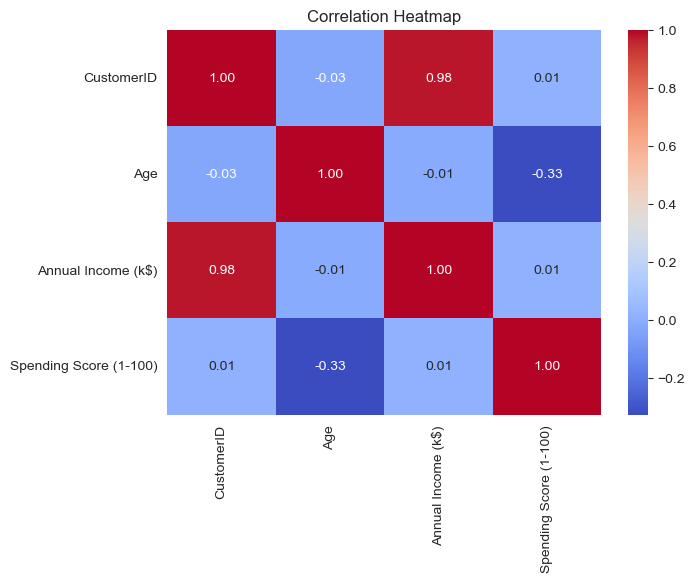

In [20]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [21]:
# Encode Gender column: Male -> 0, Female -> 1
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Select features for clustering
# We use Annual Income and Spending Score as main features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the features — important for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print("Shape:", X_scaled.shape)

Data scaled successfully!
Shape: (200, 2)


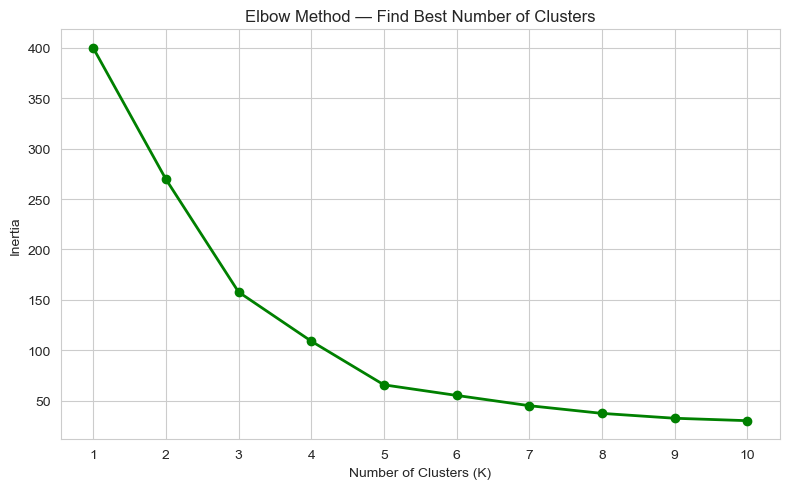

Look at the chart — the best K is where the curve bends like an elbow


In [47]:
# The Elbow Method helps us find the best K value
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='green', linewidth=2)
plt.title('Elbow Method — Find Best Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Look at the chart — the best K is where the curve bends like an elbow")

In [23]:
# From elbow method K=5 is the best value for this dataset
best_k = 5

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering done!")
print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering done!
Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [24]:
# Check silhouette score — measures how good the clusters are
# Score closer to 1.0 means better clusters
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5547


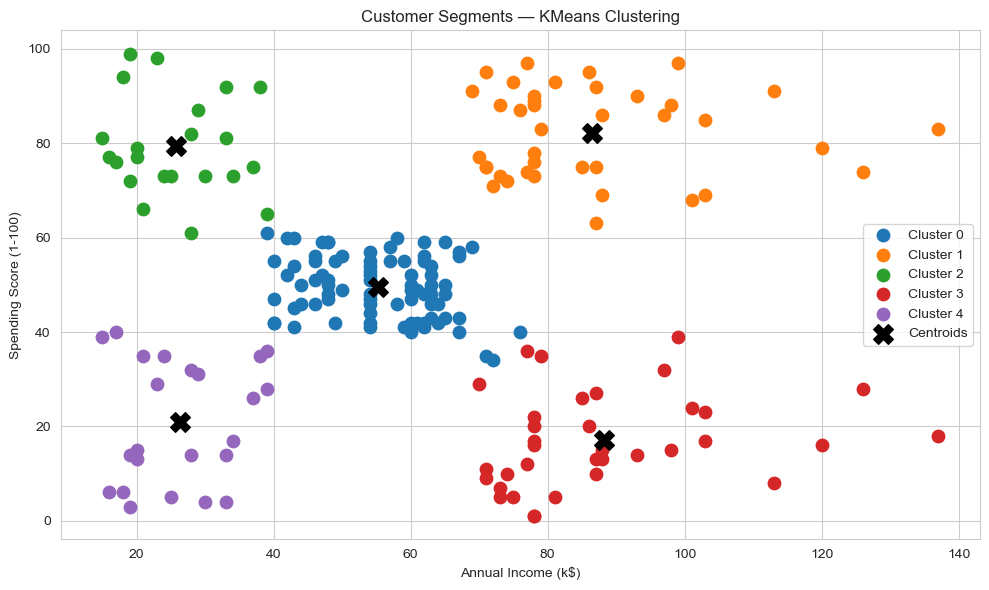

In [25]:
# Plot the clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(best_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {i}',
        s=80
    )

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], 
            c='black', marker='X', s=200, label='Centroids')

plt.title('Customer Segments — KMeans Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

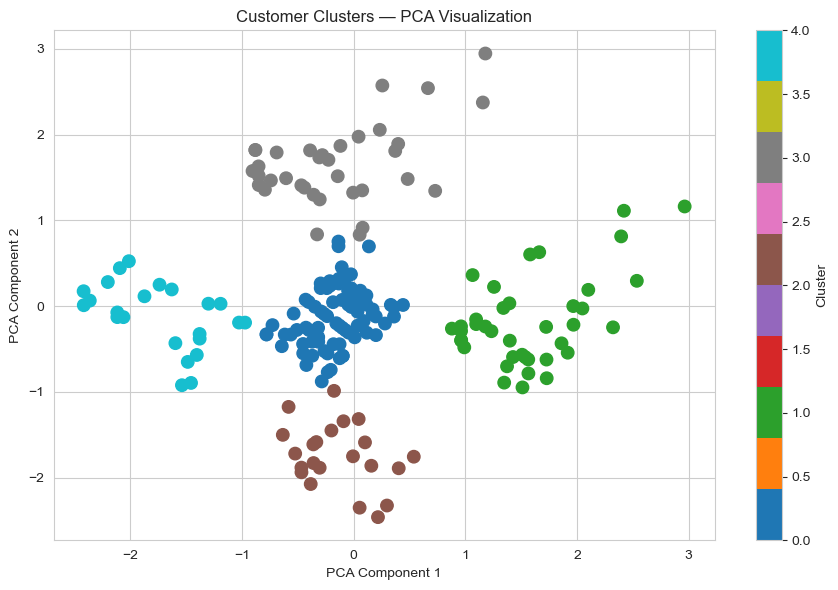

In [26]:
# PCA reduces data to 2 dimensions for easy visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df['Cluster'], cmap='tab10', s=80)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Clusters — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

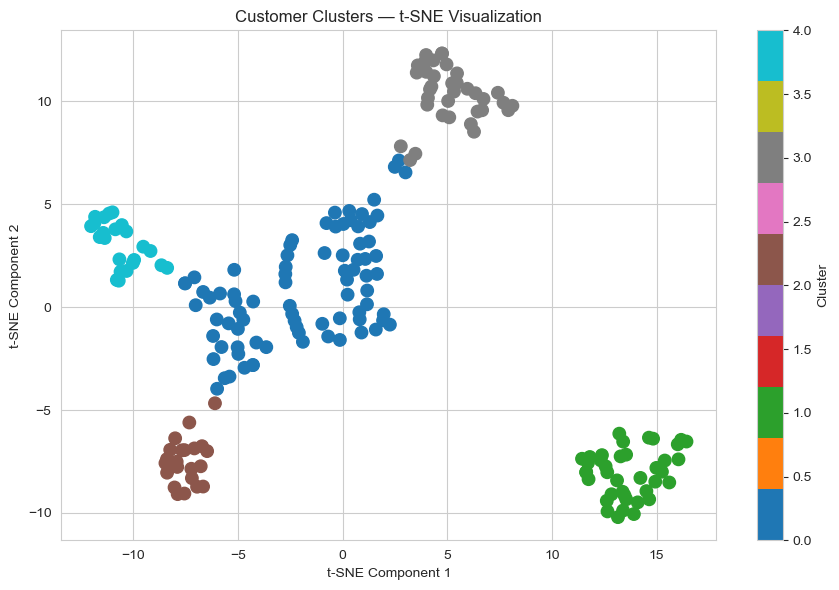

In [27]:
# t-SNE also reduces dimensions but captures more complex patterns
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE result
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=df['Cluster'], cmap='tab10', s=80)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Clusters — t-SNE Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

In [28]:
# See the average values for each cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 
                                          'Spending Score (1-100)']].mean().round(1)
print("=== Cluster Summary ===")
print(cluster_summary)

=== Cluster Summary ===
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


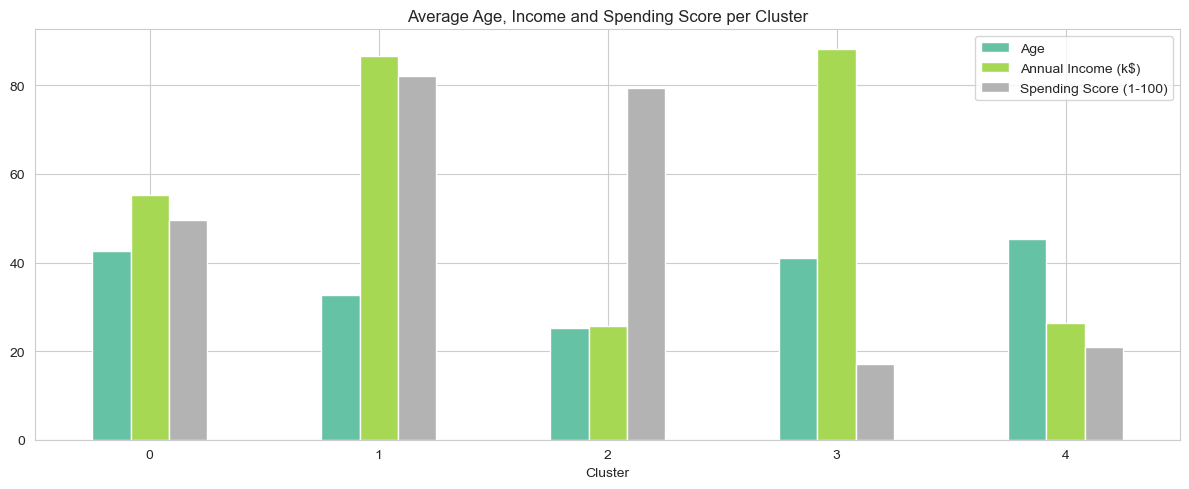

In [29]:
# Visualize cluster summary as bar charts
cluster_summary.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Average Age, Income and Spending Score per Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

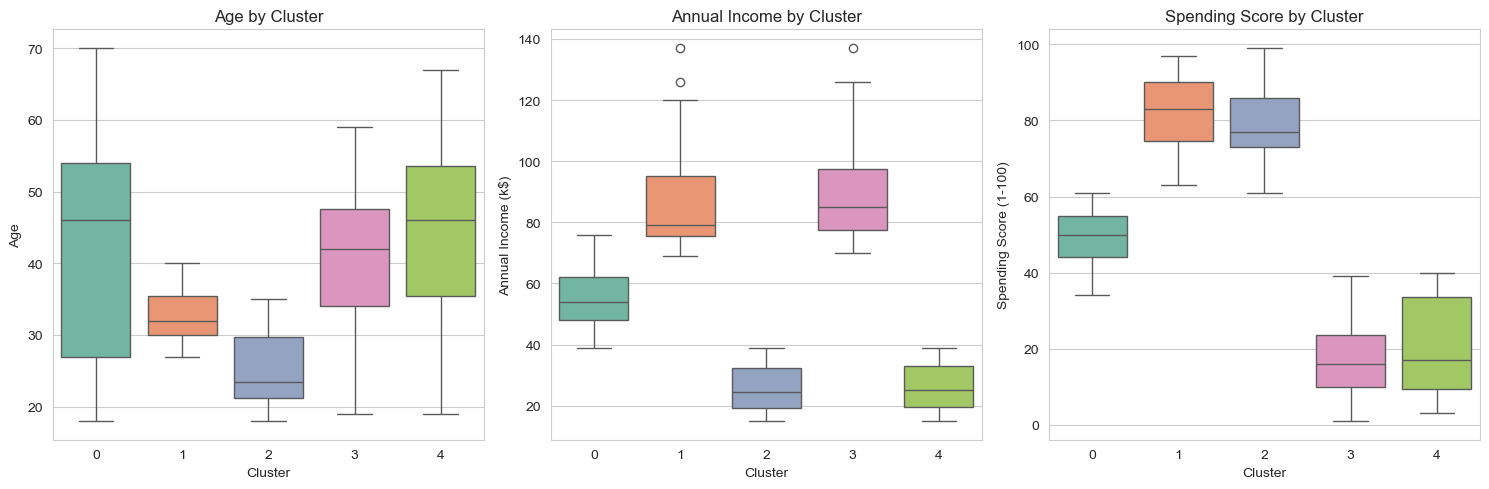

In [30]:
# Box plots for each feature by cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='Cluster', y='Age', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Age by Cluster')

sns.boxplot(x='Cluster', y='Annual Income (k$)', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Annual Income by Cluster')

sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df, palette='Set2', ax=axes[2])
axes[2].set_title('Spending Score by Cluster')

plt.tight_layout()
plt.show()

In [31]:
# Assign meaningful names to each cluster based on their characteristics
cluster_labels = {
    0: 'Low Income, Low Spenders',
    1: 'High Income, Low Spenders',
    2: 'Medium Income, Medium Spenders',
    3: 'Low Income, High Spenders',
    4: 'High Income, High Spenders'
}

df['Segment'] = df['Cluster'].map(cluster_labels)

print("=== Customer Segment Distribution ===")
print(df['Segment'].value_counts())

=== Customer Segment Distribution ===
Segment
Low Income, Low Spenders          81
High Income, Low Spenders         39
Low Income, High Spenders         35
High Income, High Spenders        23
Medium Income, Medium Spenders    22
Name: count, dtype: int64


## Marketing Strategies per Segment

Cluster 0 — Low Income, Low Spenders:
- Offer discount deals and budget friendly products
- Send promotional coupons to increase spending

Cluster 1 — High Income, Low Spenders:
- These customers have money but are not spending
- Target them with premium product campaigns and loyalty rewards

Cluster 2 — Medium Income, Medium Spenders:
- Most average customers
- Offer membership programs and moderate discounts

Cluster 3 — Low Income, High Spenders:
- They spend a lot despite low income — risk of churn
- Offer installment payment options and budget friendly premium deals

Cluster 4 — High Income, High Spenders (VIP Customers):
- These are the best customers
- Offer exclusive VIP membership, early access to new products
- Provide personalized shopping experiences

## Conclusion

- Applied KMeans clustering to segment 200 mall customers into 5 groups
- Used Elbow Method to find the optimal number of clusters (K=5)
- Silhouette Score confirmed the quality of clusters
- Visualized clusters using both PCA and t-SNE
- Identified 5 distinct customer segments based on income and spending behavior
- High Income High Spenders are the most valuable customers (VIP segment)
- Each segment was given a tailored marketing strategy
- Random Forest was not used here as this is unsupervised learning (no labels)